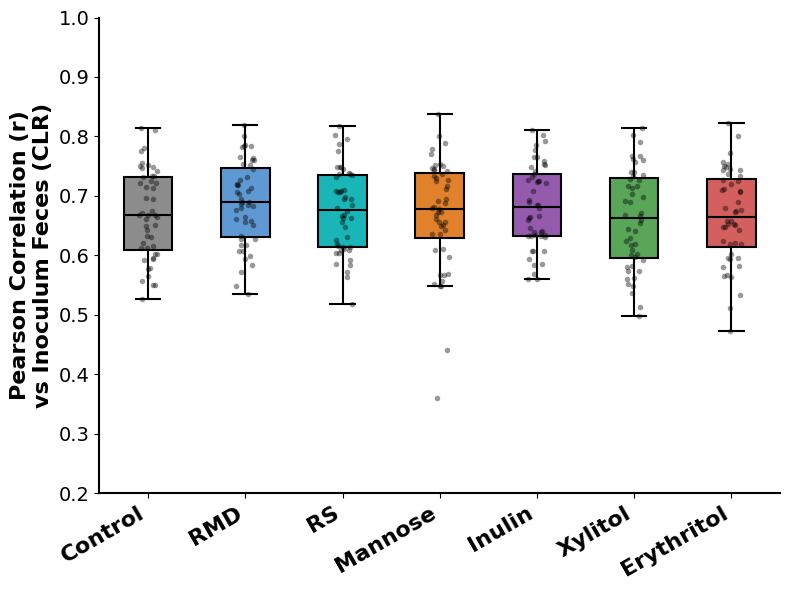

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats.mstats import gmean
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("(KULFFI)_16S_Genus_level.csv")
bac_cols = [c for c in df.columns if c.startswith('d__Bacteria')]
clusters = df['Cluster'].unique()

feat_map = {
    'CUL': 'Control',
    'Resistant maltodextrin': 'RMD',
    'Resistant starch': 'RS',
    'Mannose': 'Mannose',
    'Inulin': 'Inulin',
    'Xylitol': 'Xylitol',
    'Erythritol': 'Erythritol'
}

features = ['CUL', 'Resistant maltodextrin', 'Resistant starch', 'Mannose', 'Inulin', 'Xylitol', 'Erythritol']
display_features = [feat_map[f] for f in features]
results = []

def clr_transform(x):
    return np.log(x / gmean(x))

for cl in clusters:
    df_cl = df[df['Cluster'] == cl]
    fec_row = df_cl[df_cl['Feature'] == 'FEC']

    if len(fec_row) == 1:
        fec_vals = fec_row[bac_cols].values[0].astype(float)

        for feat in features:
            feat_row = df_cl[df_cl['Feature'] == feat]
            if len(feat_row) == 1:
                feat_vals = feat_row[bac_cols].values[0].astype(float)

                mask_any = (fec_vals > 0) | (feat_vals > 0)
                fec_filt = fec_vals[mask_any]
                feat_filt = feat_vals[mask_any]

                if len(fec_filt) > 3:
                    pseudo_fec = fec_filt[fec_filt > 0].min() * 0.5 if len(fec_filt[fec_filt > 0]) > 0 else 1e-6
                    pseudo_feat = feat_filt[feat_filt > 0].min() * 0.5 if len(feat_filt[feat_filt > 0]) > 0 else 1e-6

                    fec_imputed = np.where(fec_filt == 0, pseudo_fec, fec_filt)
                    feat_imputed = np.where(feat_filt == 0, pseudo_feat, feat_filt)

                    fec_clr = clr_transform(fec_imputed)
                    feat_clr = clr_transform(feat_imputed)

                    corr, pval = pearsonr(fec_clr, feat_clr)

                    results.append({
                        'Donor': cl,
                        'Condition': feat_map[feat],
                        'Pearson_CLR': corr,
                        'P_value': pval
                    })

df_res = pd.DataFrame(results)

plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, ax = plt.subplots(figsize=(8, 6))

palette_colors_darker = {
    'Control': '#8C8C8C',
    'RMD': '#4C99E6',
    'RS': '#00CED1',
    'Mannose': '#ff7f0e',
    'Inulin': '#9A4CBA',
    'Xylitol': '#4CB34C',
    'Erythritol': '#E64C4C'
}

sns.boxplot(x='Condition', y='Pearson_CLR', data=df_res, order=display_features,
            palette=palette_colors_darker, width=0.5, ax=ax, showfliers=False, linewidth=1.5)

for patch in ax.patches:
    patch.set_edgecolor('black')
for line in ax.lines:
    line.set_color('black')

sns.stripplot(x='Condition', y='Pearson_CLR', data=df_res, order=display_features,
              color='black', alpha=0.4, size=4, jitter=True, ax=ax)

ax.set_ylabel("Pearson Correlation (r)\nvs Inoculum Feces (CLR)", fontsize=16, fontweight='bold')
ax.set_xlabel("", fontsize=14)

y_min = np.floor(df_res['Pearson_CLR'].min() * 10) / 10 - 0.1
ax.set_ylim(bottom=y_min, top=1.0)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=16, fontweight='bold')

yticks = ax.get_yticks()
ax.set_yticks(yticks)
ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=14, fontweight='normal')

plt.tight_layout()

output_file = "Figure_S4b_LargerFont.pdf"
plt.savefig(output_file, dpi=600, format='pdf', bbox_inches='tight', transparent=True)